In [2]:
!pip install scikit-learn matplotlib pandas numpy seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 8.3/8.3 MB 53.4 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ----------------- ---------------------- 16.3/37.3 MB 77.1 MB/s eta 0:00:01
   --------------------------------- ------ 31.5/37.3 MB 76.4 MB/s eta 0:00:01
   ---------------------------------------  37.2/37.3 MB 76.6 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 59.8 MB/s  0:00:00

   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- -------------

In [3]:
# NumPy, Pandas, Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Datasets
from sklearn.datasets import (
    make_classification,
    make_regression,
    load_breast_cancer,
    load_diabetes
)

# Train-Test Split
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    ConfusionMatrixDisplay
)

In [4]:
# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')

sns.set_palette('husl')

np.random.seed(42)

print("All libraries loaded successfully!")

print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")

All libraries loaded successfully!
NumPy: 2.4.6 | Pandas: 3.0.3


In [5]:
# Dataset Preparation

# Classification Dataset - Breast Cancer
cancer = load_breast_cancer()

X_clf, y_clf = cancer.data, cancer.target

# Split data into train and test sets
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42
)

# Feature scaling (important for Logistic Regression and SVM)
scaler_c = StandardScaler()

X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c = scaler_c.transform(X_test_c)

# --------------------------------------------------

# Regression Dataset - Diabetes
diabetes = load_diabetes()

X_reg, y_reg = diabetes.data, diabetes.target

# Split data into train and test sets
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Feature scaling
scaler_r = StandardScaler()

X_train_r = scaler_r.fit_transform(X_train_r)
X_test_r = scaler_r.transform(X_test_r)

# --------------------------------------------------
# Quick Data Summary
# --------------------------------------------------

print("CLASSIFICATION DATASET (Breast Cancer)")

print(f"Train: {X_train_c.shape} | Test: {X_test_c.shape}")

print(
    f"Class Balance - Malignant: {(y_clf == 0).sum()} | "
    f"Benign: {(y_clf == 1).sum()}"
)

print("\nREGRESSION DATASET (Diabetes)")

print(f"Train: {X_train_r.shape} | Test: {X_test_r.shape}")

print(
    f"Target Range: [{y_reg.min():.0f}, {y_reg.max():.0f}]"
)

CLASSIFICATION DATASET (Breast Cancer)
Train: (455, 30) | Test: (114, 30)
Class Balance - Malignant: 212 | Benign: 357

REGRESSION DATASET (Diabetes)
Train: (353, 10) | Test: (89, 10)
Target Range: [25, 346]


In [6]:
# STUDENT TASKS
#1. Print the feature names of breast cancer dataset
print("Feature names:", cancer.feature_names[:5])

Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


In [7]:
#2. Caldulate and print class imbalance ratio (malignant/benign)
# Calculate class counts

Malignant = (y_clf == 0).sum()
Benign = (y_clf == 1).sum()

# Calculate imbalance ratio
imbalance_ratio = Malignant / Benign

# Print result
print(f"Class imbalance ratio: {imbalance_ratio:.2f}")

Class imbalance ratio: 0.59


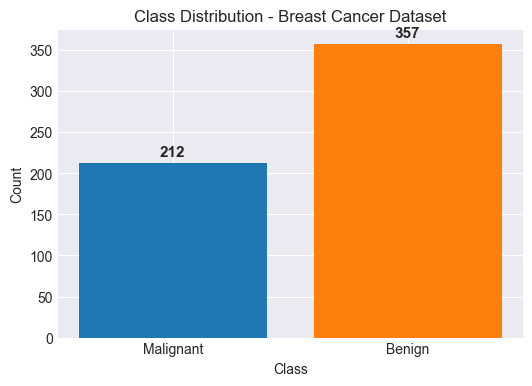

In [8]:
#3. Plot a bar chart showing class distribution
# Plot class distribution

plt.figure(figsize=(6, 4))

classes = ['Malignant', 'Benign']
counts = [Malignant, Benign]

# Create bar chart
bars = plt.bar(
    classes,
    counts,
    color=['tab:blue', 'tab:orange']
)

# Add data labels on top of each bar
for bar, val in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{val}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution - Breast Cancer Dataset")

plt.show()

Logistic Regression: Accuracy = 0.9737
Random Forest: Accuracy = 0.9649
Gradient Boosting: Accuracy = 0.9561


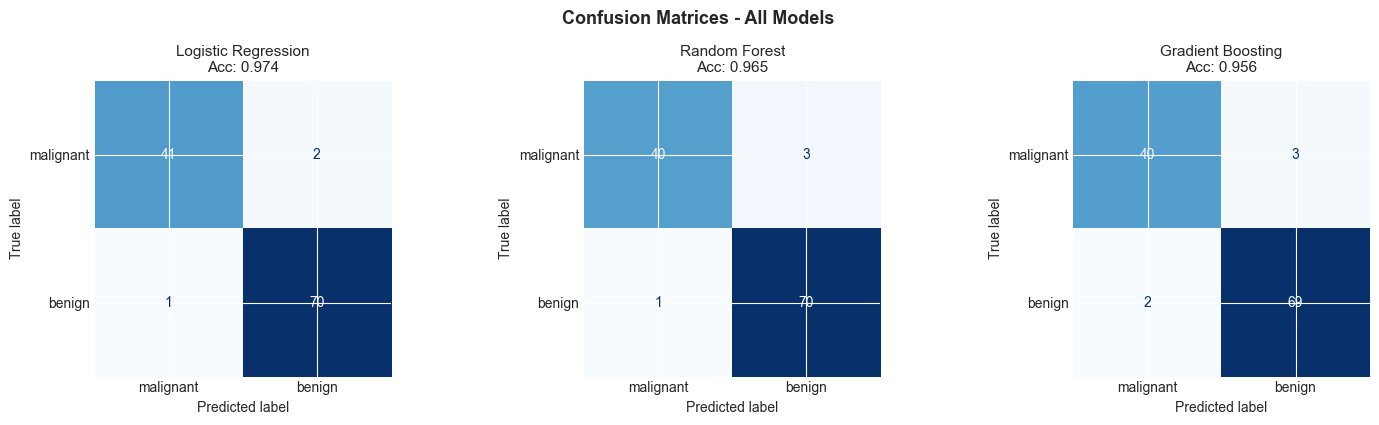

In [9]:
# Accuracy and Confusion Matrix

# Train three classifiers for comparison
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )
}

results = {}

for name, model in models.items():

    # Train model
    model.fit(X_train_c, y_train_c)

    # Predictions
    y_pred = model.predict(X_test_c)

    # Prediction probabilities
    y_proba = model.predict_proba(X_test_c)[:, 1]

    # Store results
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy_score(y_test_c, y_pred),
        'cm': confusion_matrix(y_test_c, y_pred)
    }

    print(f"{name}: Accuracy = {results[name]['accuracy']:.4f}")

# --------------------------------------------------
# Visualize Confusion Matrices
# --------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):

    disp = ConfusionMatrixDisplay(
        confusion_matrix=res['cm'],
        display_labels=cancer.target_names
    )

    disp.plot(
        ax=ax,
        colorbar=False,
        cmap='Blues'
    )

    ax.set_title(
        f"{name}\nAcc: {res['accuracy']:.3f}",
        fontsize=11
    )

plt.tight_layout()

plt.suptitle(
    "Confusion Matrices - All Models",
    y=1.05,
    fontsize=13,
    fontweight='bold'
)

plt.show()

In [10]:
# TASK 2 - Confusion Matrix Deep Dive

# Pick the Logistic Regression model's confusion matrix
# Recall: confusion_matrix returns:
# [[TN, FP],
#  [FN, TP]]

logistic_reg_cm = results['Logistic Regression']['cm']

print(logistic_reg_cm)

# Example Output:
# [[41  2]
#  [ 1 70]]

# Extract TN, FP, FN, TP manually

TN = logistic_reg_cm[0][0]
FP = logistic_reg_cm[0][1]
FN = logistic_reg_cm[1][0]
TP = logistic_reg_cm[1][1]

print(f"TN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")

[[41  2]
 [ 1 70]]
TN: 41, FP: 2, FN: 1, TP: 70


In [11]:
# 3. Calculate accuracy from scratch (without sklearn) and verify it matches

# Accuracy = Correct Predictions / Total Predictions
accuracy = (TP + TN) / (TP + TN + FP + FN)

# Print manually calculated accuracy
print(f"Accuracy: {accuracy:.4f}")

# Print sklearn calculated accuracy for comparison
print(f"Sklearn Accuracy: {results['Logistic Regression']['accuracy']:.4f}")

Accuracy: 0.9737
Sklearn Accuracy: 0.9737
